In [194]:
import math
import numpy as np

## Extraction length test

In [195]:
from helpers.utils import read_matrix, randomness_extraction_length_qkd

In [196]:
EPS_SEC1 = 2**(-23) # original
# security (trusted intervalle) for sampling error on the 2 basis-subsets
# EPS_SEC2=2**(-35)
EPS_SEC2 = 2**(-23) # original
EPS_COR=2**(-24)

def estimate_leak(initial_length, measured_qber):
        #verification_length = initial_length//2
        remaining_key_length = initial_length//2

        #print(initial_length)
        Hldpc, eccblock = read_matrix(remaining_key_length, measured_qber)
        

        if remaining_key_length < eccblock: # Insecure case    
            return None, None

        truncated_key_length=(remaining_key_length // eccblock) * eccblock

        leak = (remaining_key_length // eccblock) * Hldpc.shape[0]
        return leak, truncated_key_length


def estimate_final_key_length(initial_length, measured_qber):
    leak, truncated_key_length = estimate_leak(initial_length, measured_qber)
    if leak == None:
         return 0
    
    verification_length = initial_length // 2
    #print(truncated_key_length, verification_length)
    l = randomness_extraction_length_qkd(truncated_key_length, verification_length, leak, q=measured_qber, eps_sec=EPS_SEC1, eps_cor=EPS_COR)
    return l


print(f"{'qber':>6} {'initial_length':>15} {'length':>15} ")
for measured_qber in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06]:
    for initial_length in [9000, 10000, 11000, 100000, 600000, 1000000]:
        #print(estimate_final_key_length(initial_length, measured_qber))
        try:
            print(f"{measured_qber:>6} {initial_length:>15} {estimate_final_key_length(initial_length, measured_qber):>15} ")
            #print(f"measured_qber: {measured_qber}, initial_length: {initial_length}, l: {estimate_final_key_length(initial_length, measured_qber)}")
        except Exception:
            print(f"{measured_qber:>6} {initial_length:>15} {'-':>15} ")

  qber  initial_length          length 
  0.01            9000               0 
  0.01           10000               0 
  0.01           11000               0 
  0.01          100000           21726 
  0.01          600000          153873 
  0.01         1000000          266500 
  0.02            9000               0 
  0.02           10000               0 
  0.02           11000               0 
  0.02          100000           19487 
  0.02          600000          138358 
  0.02         1000000          239580 
  0.03            9000               0 
  0.03           10000               0 
  0.03           11000               0 
  0.03          100000           17411 
  0.03          600000          124304 
  0.03         1000000          215339 
  0.04            9000               0 
  0.04           10000               0 
  0.04           11000               0 
  0.04          100000           15471 
  0.04          600000          111354 
  0.04         1000000          193076 


In [197]:
def invert_length(target_final_length, qber,
                   lo=10000, hi=30_000_00, tol=0):
    """
    Finds the smallest initial_length such that l1 (or l2) >= target_final_length,
    for a given measured_qber. Assumes the function is non-decreasing in initial_length.
    """
    def f(x):
        l = estimate_final_key_length(x, qber)
        return l

    # Make sure the target is even achievable within [lo, hi]
    #print("test1")
    f_hi = f(hi)
    if f_hi < target_final_length:
        raise ValueError(f"Target {target_final_length} not reachable even at hi={hi} "
                          f"(got {f_hi}). Increase hi.")

    #print("test2")
    f_lo = f(lo)
    if f_lo >= target_final_length:
        return lo  # already satisfied at the lower bound

    #print("test3")
    while hi - lo > tol:
        mid = (lo + hi) // 2
        if f(mid) >= target_final_length:
            hi = mid
        else:
            lo = mid + 1

    return hi

In [198]:
#print("??", flush=True)
for l in [100, 1000, 2000, 5000, 10000]:
    #print("huh", flush=True)
    for qber in [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06]:
        print(l, qber)
        i = invert_length(l, qber)
        print(i)
    

100 0.005
12288
100 0.01
12288
100 0.015
12288
100 0.02
12288
100 0.025
12288
100 0.03
12288
100 0.035
12288
100 0.04
12288
100 0.045
24486
100 0.05
24576
100 0.055
27896
100 0.06
32768
1000 0.005
12288
1000 0.01
12288
1000 0.015
12288
1000 0.02
12288
1000 0.025
12288
1000 0.03
12288
1000 0.035
13054
1000 0.04
17994
1000 0.045
34646
1000 0.05
40960
1000 0.055
49152
1000 0.06
53296
2000 0.005
24576
2000 0.01
24576
2000 0.015
24576
2000 0.02
24576
2000 0.025
24576
2000 0.03
24576
2000 0.035
24576
2000 0.04
24576
2000 0.045
49152
2000 0.05
57344
2000 0.055
65536
2000 0.06
73728
5000 0.005
36864
5000 0.01
36864
5000 0.015
36864
5000 0.02
36864
5000 0.025
36864
5000 0.03
36864
5000 0.035
38598
5000 0.04
49152
5000 0.045
90112
5000 0.05
98304
5000 0.055
106496
5000 0.06
122880
10000 0.005
49152
10000 0.01
61440
10000 0.015
61440
10000 0.02
61440
10000 0.025
61440
10000 0.03
61548
10000 0.035
73728
10000 0.04
73728
10000 0.045
139264
10000 0.05
155648
10000 0.055
173858
10000 0.06
196608


In [199]:
print(estimate_final_key_length(12288, 0.005))

1584


In [200]:
for qber in [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06]:
    for initial_length in [10000, 13000, 15000, 20000, 30000, 50000, 100000, 500000]:
        l = estimate_final_key_length(initial_length, qber)
        print(l)

0
1606
1659
1751
4364
10175
22919
133831
0
1498
1549
1638
4115
9629
21726
126842
0
1393
1443
1529
3874
9104
20584
120276
0
1290
1339
1423
3641
8597
19487
114055
0
1190
1238
1320
3415
8106
18431
108125
0
1093
1139
1219
3195
7631
17411
102447
0
998
1043
1121
2981
7170
16425
96992
0
906
950
1026
2772
6722
15471
91737
0
0
0
34
522
2191
6353
46515
0
0
0
0
324
1768
5454
41525
0
0
0
0
131
1356
4580
36690
0
0
0
0
0
955
3730
32001


In [201]:

def h(e): 
    if e == 0 or e == 1: 
        return 0
    elif e < 0 or e > 1.0:
        return 1
    return (-e * np.log(e) - (1 - e) * np.log(1-e)) / np.log(2)


# n should be >= 10^4 or 10^5
def randomness_extraction_length_qkd(n, k, leak, q, eps_sec, eps_cor):
    """
    computes the number of extractable secure bits, as per Tomamichel and Leverrier
    :param n: rawkey length
    :param k: length of check bits / decommitment string
    :param leak: legnth of the syndrome
    :param q: tolerable qber
    :eps_sec: security parameter
    :eps_cor: correctness parameter
    """
    q2 = q + np.sqrt((n+k)*(k+1)* np.log(2/eps_sec)/(n*k*k)) # ~sqrt(47/n)
    small = np.log(2/(eps_sec*eps_sec*eps_cor))/np.log(2) # ~100
    final_length_fs = int(n - leak - (h(q2) * n) - small)

    return max(int(final_length_fs), 0)

In [202]:
def basis_reconciliation_num_qubits_reconciliation(resulting_num_qubits, confidence):
    #failure_prob = 1 - confidence
    a = 0.25
    b = np.log(1-confidence) - resulting_num_qubits
    c = math.pow(resulting_num_qubits, 2)
    x1 = (- b + np.sqrt(math.pow(b, 2) - 4 * a * c))/ (2 * a)
    x2 = (- b - np.sqrt(math.pow(b, 2) - 4 * a * c))/ (2 * a)
    return x1, x2

confidence = 0.99
for i in [1000, 10000, 100000]:
    x1, x2 = basis_reconciliation_num_qubits_reconciliation(i, confidence)
    print(1 - 2 * i/x1)
    print(1 - 2 * i/x2)
    print(x1, x2)
    # basically, x1 is what we want, not x2.

0.0914757746699929
-0.10068611504196912
2201.372230083938 1817.048450660014
0.029891519373085096
-0.030812553410282773
20616.251068205656 19402.1696125383
0.009551110612017744
-0.009643214015737422
201928.6428031475 198089.77787759644


## Calculating repudiation and forgery possibilities

In [204]:
import numpy as np
from scipy.stats import binom
import math
from helpers.utils import writecsv

In [205]:
def repudiation_prob(n, bM, bH, bH_prime, e_max):
    right_term = (bM + 4 * n * bH)/math.pow(2, bH_prime - 1)
    left_term = 1
    for i in range(e_max):
        left_term *= (n/2 - i)/(n-i)

    return max(left_term, right_term)


def forgery_prob(n, bM, bH, e_max):
    a = n//2 - e_max
    b = n//2
    c = bM * math.pow(2, 1 - bH)
    #print(a, b, c)

    Xi = binom.sf(a - 1, b, c)
    return Xi


def compute_combinatorial_term(n, e_max):
    left_term = 1
    for i in range(e_max):
        left_term *= (n//2 - i)/(n-i)
    return left_term
    

In [256]:
import math

def find_optimal_params(func, bM, total_budget=1e-10,
                          n_range=range(2, 500, 2),      # even n, per protocol structure
                          bH_range=None):             # emax <= n/2

    best = None  # (lP, n, bH, emax, b_prime_H)
    if bH_range is None:
        bH_range=range(int(np.log2(bM) + 1), 128)

    for n in n_range:
        for bH in bH_range:
            # quick necessary check before looping emax: p = bM * 2^(1-bH) <= 1
            p = bM * 2**(1 - bH)
            if p > 1:
                continue  # bH too small at this bM, skip entirely

            for emax in range(0, n // 2 + 1):
                eps_for = forgery_prob(n, bM, bH, emax) 
                remaining = total_budget - eps_for
                if remaining <= 0:
                    continue

                comb_term = compute_combinatorial_term(n, emax)
                if comb_term > remaining:
                    continue

                # solve b'_H analytically, then round UP (ceil) since b'_H must be an integer
                # and rounding down could violate the security bound
                raw_b_prime_H = math.log2((bM + 4*n*bH) / remaining) + 1
                b_prime_H = math.ceil(raw_b_prime_H)

                # verify the rounded integer value actually satisfies the bound
                eps_prime = (bM + 4*n*bH) / (2**(b_prime_H - 1))
                eps_rep = max(comb_term, eps_prime)
                total = eps_for + eps_rep

                if total > total_budget:
                    continue  # shouldn't happen given ceil, but guard anyway

                l = func(n, bH, b_prime_H)

                if best is None or l < best[0]:
                    best = (l, n, bH, emax, b_prime_H, total)

    return best

In [207]:
def l_total(n, bH, b_prime_H):
    return 9*n*bH + n*math.log2(n) + 5*b_prime_H

def l_AliceBob(n, bH, b_prime_H):
    return 3*n*bH 

def l_BobCharlie(n, bH, b_prime_H):
    return 3*n*bH + n*math.log2(n) + 5*b_prime_H

def l_old(n, bH, b_prime_H):
    return 6*n*bH + n*math.log2(n) + 7*b_prime_H

def l_weird(n, bH, b_prime_H): 
    return 1000*n*bH + 0.001*n*math.log2(n) + 0.001*b_prime_H

In [258]:
find_optimal_params(l_total, 80)

(8949.930011877657, 66, 14, 24, 47, np.float64(8.69743077690184e-11))

In [ ]:
path = "log/params_l_AliceBob.csv" #bM,l_total,n,bH,emax,b_prime_H,total_error
for bM_test in np.arange(80, 800, 80): # 80 to 80_000_000_000
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(800, 8_000, 800): 
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(8_000, 80_000, 8_000): 
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(80_000_000_000, 800_000, 80_000): 
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(800_000, 8_000_000, 800_000): 
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(8_000_000, 80_000_000, 8_000_000): # 80 to 80_000_000_000
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(80_000_000, 800_000_000, 80_000_000): # 80 to 80_000_000_000
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(800_000_000, 8_000_000_000, 800_000_000): # 80 to 80_000_000_000
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(8_000_000_000, 80_000_000_000, 8_000_000_000): # 80 to 80_000_000_000
    res = find_optimal_params(l_AliceBob, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

res = find_optimal_params(l_AliceBob, bM=80_000_000_000)
writecsv(path, [80_000_000_000, res[0], res[1], res[2], res[3], res[4], res[5]], False)

### Plotting Graphs

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import csv
import numpy as np

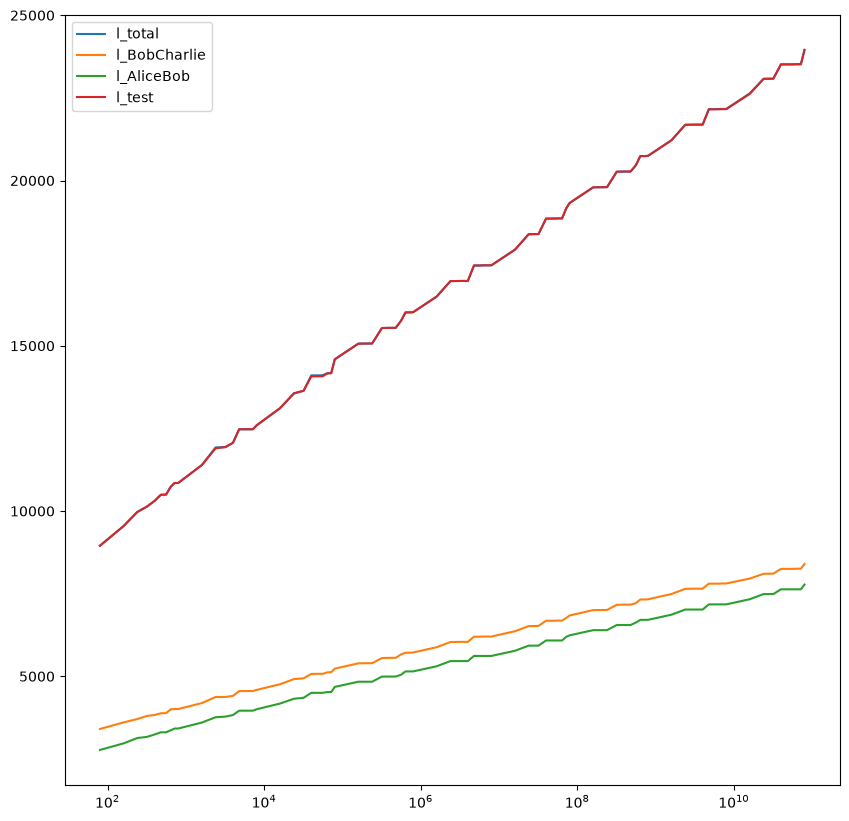

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))



# l_total
x1 = []
y1 = []
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x1.append(int(row['bM']))
        y1.append(float(row['l_total']))
ax.plot(x1, y1, label=f'l_total')

#l_BobCharlie
x2 = []
y2 = []
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x2.append(int(row['bM']))
        y2.append(float(row['l_BobCharlie']))
ax.plot(x2, y2, label=f'l_BobCharlie')

#l_AliceBob
x3 = []
y3 = []
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x3.append(int(row['bM']))
        y3.append(float(row['l_AliceBob']))
ax.plot(x3, y3, label=f'l_AliceBob')

#test = l_BobCharlie + l_AliceBob + l_AliceCharlie = l_BobCharlie + 2 * l_AliceBob 
y4 = [y2[i] + y3[i]*2 for i in range(len(x3))]
ax.plot(x3, y4, label=f'l_test')

ax.set_xscale('log', base=10)
ax.legend()

In [14]:
print(y1 == y4)
for i in range(len(x3)):
    if y1[i] != y4[i]:
        print(y1[i], y4[i])

False
11924.930011877657 11898.413435736511
13564.413435736511 13554.422865343337
14104.413435736511 14070.422865343337
14104.413435736511 14075.422865343337
14109.413435736511 14075.422865343337
22159.42286534334 22155.078200034615
22159.42286534334 22155.078200034615
22164.42286534334 22155.078200034615
22164.42286534334 22160.078200034615
22164.42286534334 22160.078200034615
22637.42286534334 22621.078200034615


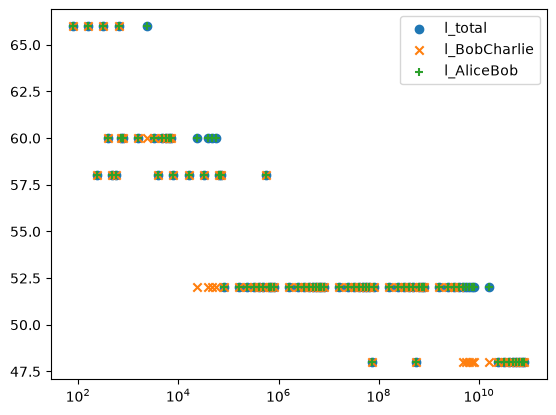

In [210]:
fig, ax = plt.subplots()



# l_total
x1 = []
y1 = []
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x1.append(int(row['bM']))
        y1.append(float(row['n']))
ax.scatter(x1, y1, label=f'l_total', marker = 'o')

#l_BobCharlie
x2 = []
y2 = []
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x2.append(int(row['bM']))
        y2.append(float(row['n']))
ax.scatter(x2, y2, label=f'l_BobCharlie', marker = 'x')

#l_AliceBob
x3 = []
y3 = []
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x3.append(int(row['bM']))
        y3.append(float(row['n']))
ax.scatter(x3, y3, label=f'l_AliceBob', marker='+')


ax.set_xscale('log', base=10)
ax.legend()

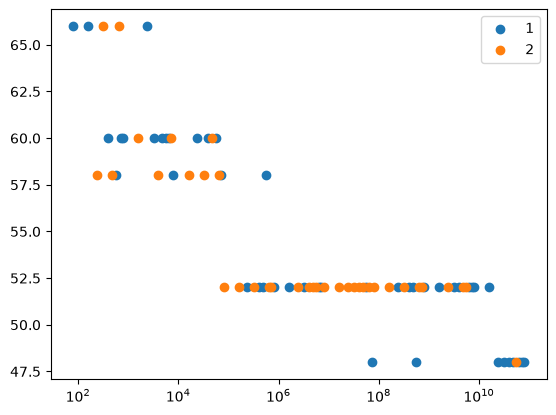

In [ ]:
# Plot to see whether 1st or 2nd term of repudiation prob was applied to investigate for pattern 
# (no pattern found)

def repudiation_prob(n, bM, bH, bH_prime, e_max):
    right_term = (bM + 4 * n * bH)/math.pow(2, bH_prime - 1)
    left_term = 1
    for i in range(e_max):
        left_term *= (n/2 - i)/(n-i)

    #print(left_term, right_term)
    if left_term > right_term:
        x = 1
    else:
        x = 2
    return x, max(left_term, right_term)

def forgery_prob(n, bM, bH, e_max):
    a = n//2 - e_max
    b = n//2
    c = bM * math.pow(2, 1 - bH)
    #print(a, b, c)

    Xi = binom.sf(a - 1, b, c)
    return Xi


fig, ax = plt.subplots()


# l_total
x1 = []
y1 = []
x2 = []
y2 = []
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        bM = int(row['bM'])
        n =int(row['n'])
        bH_prime = int(row['b_prime_H'])
        bH = int(row['bH'])
        e_max = int(row['emax'])
        x, prob = repudiation_prob(n, bM, bH,bH_prime, e_max)
        #print(forgery_prob(n, bM, bH, e_max), pro)
        if x == 1:
            x1.append(bM)
            y1.append(n)
        else:
            x2.append(bM)
            y2.append(n)          

        
        
ax.scatter(x1, y1, label=f'1')
ax.scatter(x2, y2, label=f'2')


ax.set_xscale('log', base=10)
ax.legend()

In [ ]:
from scipy.optimize import curve_fit

def log_graph(x, a, b): # function for curve-fitting the following graph data points
    return a * np.log(x) + b

[1.82131183 6.77072335] [[ 0.00059187 -0.00895968]
 [-0.00895968  0.15729031]]
a = 1.8213 ± 0.0243
b = 6.7707 ± 0.3966
[1.82131183 6.77072335] [[ 0.00059187 -0.00895968]
 [-0.00895968  0.15729031]]
a = 1.8213 ± 0.0243
b = 6.7707 ± 0.3966
[1.85283904 6.8056643 ] [[ 0.00056771 -0.0085939 ]
 [-0.0085939   0.15086893]]
a = 1.8528 ± 0.0238
b = 6.8057 ± 0.3884


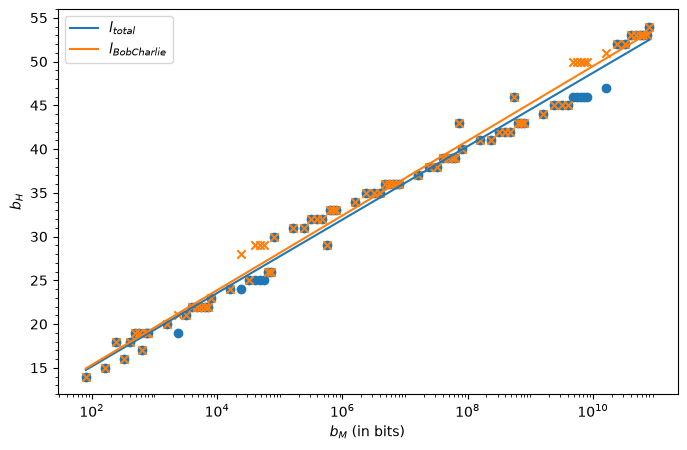

In [226]:
fig, ax = plt.subplots(figsize=(8, 5))



# l_total
x1 = []
y1 = []
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x1.append(int(row['bM']))
        y1.append(float(row['bH']))
ax.scatter(x1, y1, marker="o", color='tab:blue') #, linestyle=(0, (5, 5)))

#l_AliceBob
x2 = []
y2 = []
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x2.append(int(row['bM']))
        y2.append(float(row['bH']))
#ax.scatter(x2, y2, marker="X", color='tab:orange') # linestyle="dotted")

#l_BobCharlie
x3 = []
y3 = []
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x3.append(int(row['bM']))
        y3.append(float(row['bH']))
ax.scatter(x3, y3, marker="x", color='tab:orange') #,linestyle="dotted")




# curve-fit: l_total
popt, pcov = curve_fit(log_graph, x1, y1)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x1:
    y_test.append(log_graph(x, a, b))
ax.plot(x1, y_test, label='$l_{total}$', color='tab:blue')


# curve-fit: l_AliceBob
popt, pcov = curve_fit(log_graph, x2, y2)
print(popt, pcov)

a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x2:
    y_test.append(log_graph(x, a, b))
#ax.plot(x2, y_test, label='$l_{AliceBob}$', color='tab:orange')

# curve-fit: l_BobCharlie
popt, pcov = curve_fit(log_graph, x3, y3)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x3:
    y_test.append(log_graph(x, a, b))
ax.plot(x3, y_test, label='$l_{BobCharlie}$', color='tab:orange')

ax.set_xscale('log', base=10)

## set x ticks
ax.minorticks_on()
x_major = ticker.LogLocator(base = 10.0, numticks = 5)
ax.xaxis.set_major_locator(x_major)
x_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_ylabel('$b_H$')
ax.set_xlabel('$b_M$ (in bits)')

ax.legend()


[ 703.56714285 6323.06960569] [[  10.25506677 -155.23963474]
 [-155.23963474 2725.28554196]]
a = 703.5671 ± 3.2024
b = 6323.0696 ± 52.2043
[ 233.97690227 1915.75195049] [[  1.2836316  -19.43141885]
 [-19.43141885 341.12528273]]
a = 233.9769 ± 1.1330
b = 1915.7520 ± 18.4696
[ 235.72464421 2487.7277651 ] [[  0.8860285  -13.41256402]
 [-13.41256402 235.46220234]]
a = 235.7246 ± 0.9413
b = 2487.7278 ± 15.3448


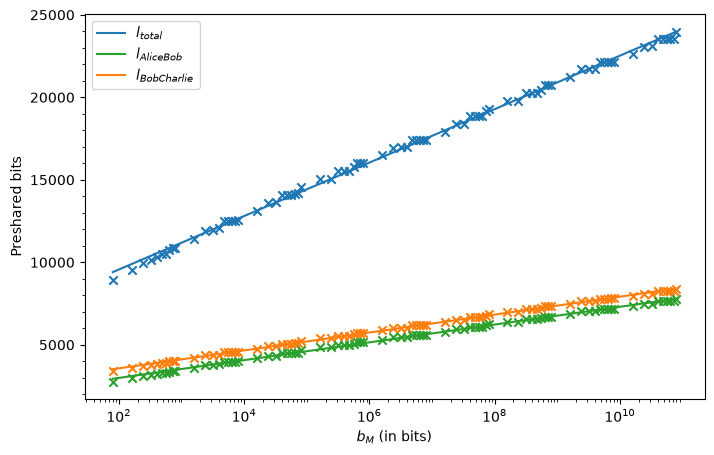

In [261]:
fig, ax = plt.subplots(figsize=(8, 5))



# l_total
x1 = []
y1 = []
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x1.append(int(row['bM']))
        y1.append(float(row['l_total']))
ax.scatter(x1, y1, marker="x", color="tab:blue") #, linestyle='dotted')


#l_BobCharlie
x3 = []
y3 = []
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x3.append(int(row['bM']))
        y3.append(float(row['l_BobCharlie']))
ax.scatter(x3, y3, marker="x", color="tab:orange") #, linestyle='dotted')

#l_AliceBob
x2 = []
y2 = []
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x2.append(int(row['bM']))
        y2.append(float(row['l_AliceBob']))
ax.scatter(x2, y2, marker="x", color="tab:green") #, linestyle='dotted')








# curve-fit: l_total
popt, pcov = curve_fit(log_graph, x1, y1)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x1:
    y_test.append(log_graph(x, a, b))
ax.plot(x1, y_test, label='$l_{total}$', color='tab:blue')


# curve-fit: l_AliceBob
popt, pcov = curve_fit(log_graph, x2, y2)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x2:
    y_test.append(log_graph(x, a, b))
ax.plot(x2, y_test, label='$l_{AliceBob}$', color='tab:green')

# curve-fit: l_BobCharlie
popt, pcov = curve_fit(log_graph, x3, y3)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x3:
    y_test.append(log_graph(x, a, b))
ax.plot(x3, y_test, label='$l_{BobCharlie}$', color='tab:orange')



ax.set_xscale('log', base=10)

## set x ticks
ax.minorticks_on()
x_major = ticker.LogLocator(base = 10.0, numticks = 5)
ax.xaxis.set_major_locator(x_major)
x_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_ylabel('Preshared bits')
ax.set_xlabel('$b_M$ (in bits)')

ax.legend()


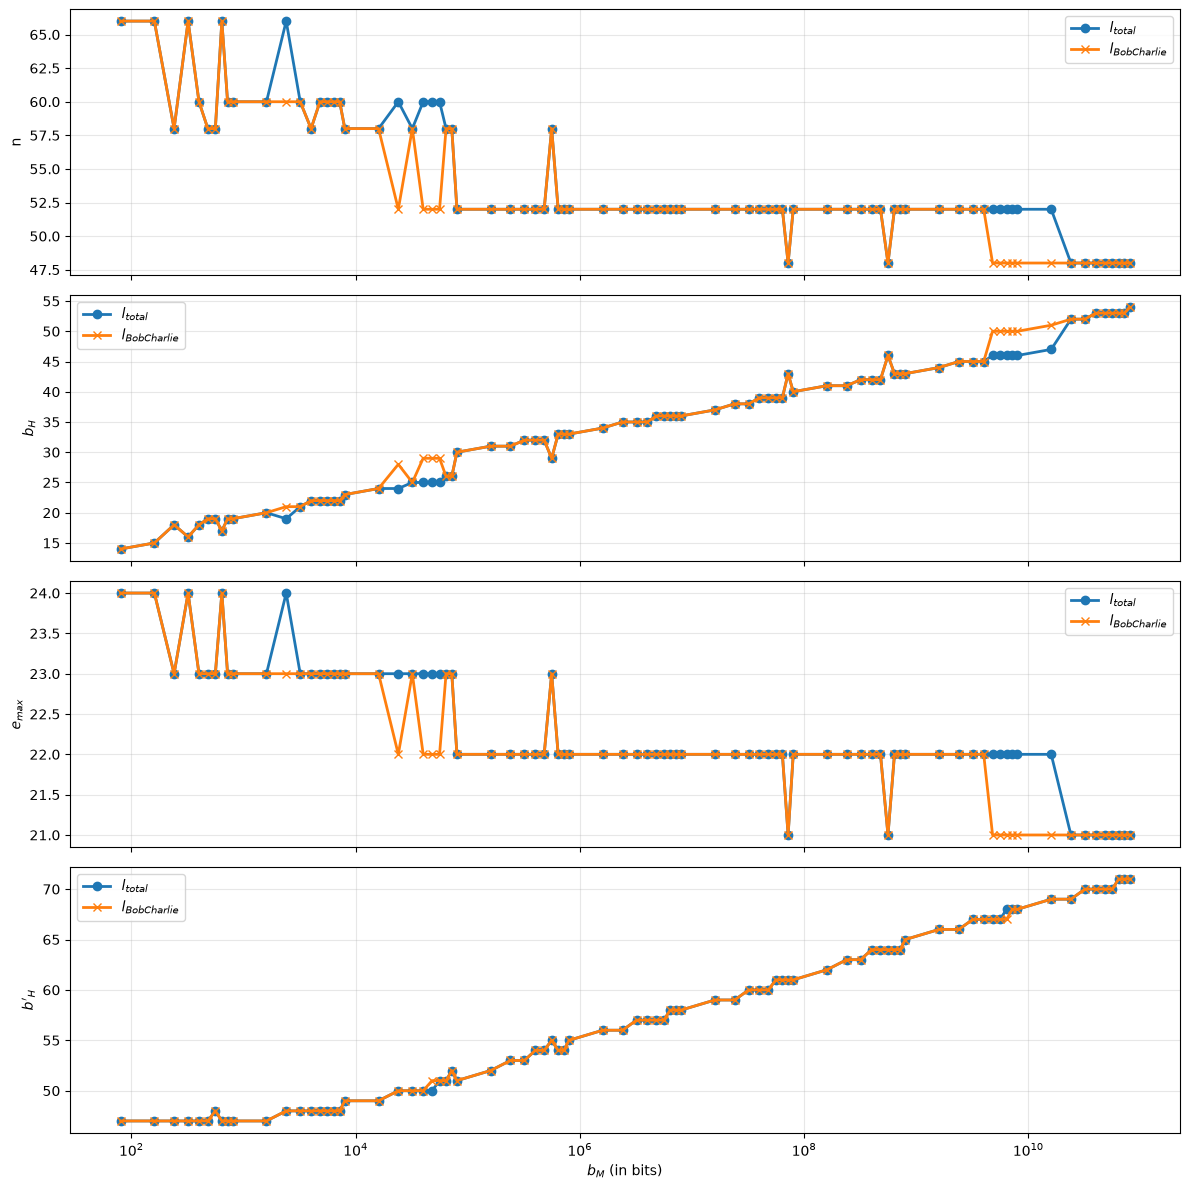

In [230]:
import matplotlib.pyplot as plt
bM_values = []
results1 = {'n':[], 'bH':[], 'emax':[], 'b_prime_H':[]}
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        bM_values.append(int(row['bM']))
        results1['n'].append(int(row['n']))
        results1['bH'].append(int(row['bH']))
        results1['emax'].append(int(row['emax']))
        results1['b_prime_H'].append(int(row['b_prime_H']))

results2 = {'n':[], 'bH':[], 'emax':[], 'b_prime_H':[]}
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        results2['n'].append(int(row['n']))
        results2['bH'].append(int(row['bH']))
        results2['emax'].append(int(row['emax']))
        results2['b_prime_H'].append(int(row['b_prime_H']))

results3 = {'n':[], 'bH':[], 'emax':[], 'b_prime_H':[]}
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        results3['n'].append(int(row['n']))
        results3['bH'].append(int(row['bH']))
        results3['emax'].append(int(row['emax']))
        results3['b_prime_H'].append(int(row['b_prime_H']))

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

params = ['n', 'bH', 'emax', 'b_prime_H']  # adjust to your actual variable names
for ax, param in zip(axes, params):
    ax.plot(bM_values, results1[param], marker='o', linewidth=2, label='$l_{total}$')
    #ax.step(bM_values, results2[param], where='post', marker='x', linewidth=2)
    ax.plot(bM_values, results3[param], marker='x', linewidth=2, label='$l_{BobCharlie}$')
    if param == 'bH':
        label = '$b_H$'
    elif param == 'emax':
        label = '$e_{max}$'
    elif param == 'b_prime_H':
        label = "$b'_{H}$"
    else:
        label = param

    ax.set_ylabel(label)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('$b_M$ (in bits)')
plt.tight_layout()


In [232]:
results1==results2

True

### Mini script for getting optimal params from existing log or finding them if not in csv

In [234]:
def get_optimal_params(bM):
    with open("log/params_l_total.csv", "r") as f:
        data = csv.DictReader(f)
        for row in data:
            if int(row['bM']) == bM:
                params = [int(row['n']), int(row['bH']), int(row['emax']), int(row['b_prime_H'])]
                return params

    l, n, bH, emax, b_prime_H, total = find_optimal_params(l_total, bM)
    params = [n, bH, emax, b_prime_H]
    return params

### Script to get timelog results and calculate mean and std. dev. 

In [235]:
bM_vals = [80, 800, 8_000, 80_000, 800_000, 8_000_000]
def get_timelog(bM, param, name):
    l = []
    with open(f"log/timelog_{name}.csv", "r") as f:
        data = csv.DictReader(f)
        for row in data:
            if int(row['bM']) == bM:
                l.append(row[param])
    return l
        

In [239]:
bM = 8000000
name = 'Alice'
print(get_timelog(bM, 'n', name), get_timelog(bM, 'e_max', name), get_timelog(bM, 'bH', name), get_timelog(bM, 'b_prime_H', name))

['52', '52', '52', '52', '52'] ['22', '22', '22', '22', '22'] ['36', '36', '36', '36', '36'] ['58', '58', '58', '58', '58']


In [188]:
bM = 8_000_000
name = 'Charlie'
a = [get_timelog(bM, 't_total', name), get_timelog(bM, 't_QKD', name), get_timelog(bM, 't_key_transfer', name), get_timelog(bM, 't_verifications_total', name), get_timelog(bM, 't_single_verification', name)]
print(a)
for res in a:
    new = [float(t) for t in res]
    mean = sum(new)/5
    std_dev = np.sqrt(sum([(x - mean)**2 for x in new])/(5-1))
    print(mean, std_dev)
print(res)

[['5722.81908175', '5289.873950874957', '5092.092289166991', '5811.460906749999', '6030.077949708037'], ['2.1921737090451643', '2.2878603750141338', '2.260874666972086', '2.233267125033308', '2.175381249981001'], ['0.0006202920340001583', '0.00033412501215934753', '0.0004438749747350812', '0.0004027499817311764', '0.0003974999999627471'], ['1585.4891624579905', '1543.4714088339824', '1490.168153082952', '1670.3879318330437', '2258.617553249991'], ['20.326557731873784', '19.787989897423614', '19.104660344055635', '21.41498480878251', '28.956536605252694']]
5589.264835649997 386.7620311806544
2.2299114252091385 0.0467058322829349
0.0004397084005177021 0.00010830874239445524
1709.626841891592 313.891064186173
21.91814587747765 4.024255622759377
['20.326557731873784', '19.787989897423614', '19.104660344055635', '21.41498480878251', '28.956536605252694']


### Generate Plots for num_qubits

In [250]:
from helpers.utils import calculate_num_qubits, invert_length
import matplotlib.pyplot as plt

In [240]:
CONFIDENCE = 0.997

/var/folders/x8/z2s685412c74m1sp9myb1f_m0000gn/T/ipykernel_45543/173864761.py:85: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  H = mmread(path).tocsr()


[30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 78000, 102000, 126000, 150000, 150000, 372000, 594000, 792000, 1014000, 1116000, 3156000, 5148000, 7140000, 9138000, 10122000, 29766000, 49314000, 68808000, 88278000, 98010000, 292218000, 486126000, 679854000, 873528000]
[30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 78000, 102000, 126000, 150000, 150000, 402000, 624000, 846000, 1062000, 1164000, 3330000, 5448000, 7536000, 9630000, 10686000, 31488000, 52188000, 72840000, 93486000, 103788000, 309624000, 515130000, 720504000, 925830000]
[30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 36000, 54000, 78000, 102000, 126000, 150000, 180000, 426000, 696000, 936000, 1164000, 1284000, 3672000, 6036000, 8370000, 10710000, 11868000, 35028000, 58110000, 81120000, 104130000, 115614000, 345090000, 574266000, 803286000, 1032252000]
[30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 30000, 54000, 54000, 78000, 102000, 15000

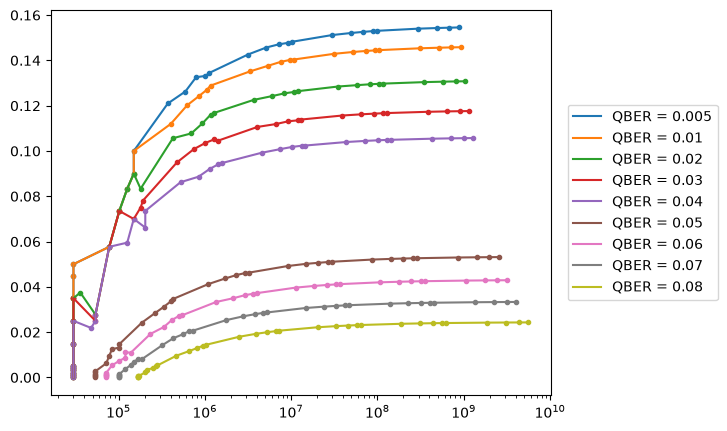

In [143]:
fig, ax = plt.subplots(figsize=(8,5))

#plt.tight_layout()
res = []
n = 1
bH_vals = list(range(1, 50, 10)) + list(range(50, 500, 100)) + list(range(500, 5000, 1000)) + list(range(5000, 50000, 10000))+ list(range(50000, 500000, 100000)) +list(range(500000, 5000000, 1000000)) + list(range(5000000, 50000000, 10000000)) # +list(range(50000000, 500000000, 100000000)) # + list(range(500000000, 5_000_000_000, 1000000000)) + list(range(5000000000, 50_000_000_000, 10000000000))
key_lengths = [3 * n * i for i in bH_vals]
for estimated_qber in [0.005, 0.01, 0.02, 0.03, 0.04,  0.05, 0.06, 0.07, 0.08]:
#for estimated_qber in [0.025,  0.05,0.07]:
#for estimated_qber in [0.005, 0.01, 0.02, 0.03]:
    num_qubits = []
    for bH in bH_vals:
        num_qubits.append(calculate_num_qubits(n, bH, estimated_qber, confidence=CONFIDENCE)[0])
        #num_qubits.append(invert_length(3 * n * bH, estimated_qber))
    #print(len(bH_vals), bH_vals)
    #print(len(num_qubits))

    test = [key_lengths[i]/num_qubits[i] for i in range(len(num_qubits))]
    #ax.plot(lengths, num_qubits)

    ax.set_xscale('log')

    #ax.set_yscale('log')
    #ax.plot(key_lengths, num_qubits)
    #ax.scatter(key_lengths, num_qubits)
    ax.plot( num_qubits, test, label=f"QBER = {estimated_qber}")
    ax.scatter(num_qubits, test, marker=".")
    res.append([key_lengths, num_qubits, estimated_qber])
    #ax.plot(num_qubits,key_lengths)
    #ax.scatter(num_qubits, test)
    #ax.plot(num_qubits, test)
    print(num_qubits)
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

fig.subplots_adjust(right=0.75)

/var/folders/x8/z2s685412c74m1sp9myb1f_m0000gn/T/ipykernel_45543/1746059355.py:69: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  H = mmread(path).tocsr()


[12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12606, 13782, 15156, 16780, 18728, 21104, 24064, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24650, 26044, 27576, 29268, 31144, 33236, 35586, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864, 36864

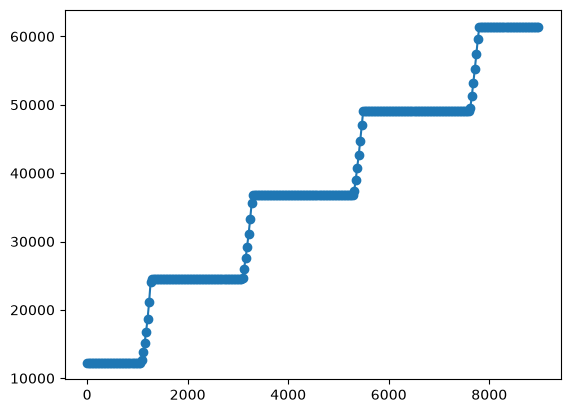

In [ ]:
fig, ax = plt.subplots()
n = 1
bH_vals = range(1, 3000, 10)
key_lengths = [3 * n * i for i in bH_vals]
#for estimated_qber in [0.005, 0.01, 0.02, 0.03,0.04,  0.05, 0.06, 0.07, 0.08]:
for estimated_qber in [0.03]:
#for estimated_qber in [0.005, 0.01, 0.02, 0.03]:
    num_qubits = []
    for bH in bH_vals:
        #num_qubits.append(calculate_num_qubits(n, bH, estimated_qber, confidence=CONFIDENCE)[0])
        num_qubits.append(invert_length(3 * n * bH, estimated_qber))

    ax.plot(key_lengths, num_qubits)
    ax.scatter(key_lengths, num_qubits)
    print(num_qubits)



/var/folders/x8/z2s685412c74m1sp9myb1f_m0000gn/T/ipykernel_45543/1746059355.py:69: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  H = mmread(path).tocsr()


[12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12288, 12606, 13172, 13782, 14442, 15156, 15934, 16780, 17708, 18728, 19854, 21104, 22498, 24064, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576

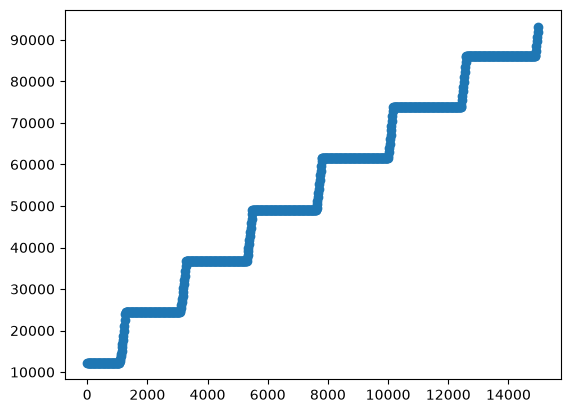

In [255]:
fig, ax = plt.subplots()
n = 1
bH_vals = range(1, 100 * 50, 5)
key_lengths = [3 * n * i for i in bH_vals]
#for estimated_qber in [0.005, 0.01, 0.02, 0.03,0.04,  0.05, 0.06, 0.07, 0.08]:
for estimated_qber in [0.03]:
#for estimated_qber in [0.005, 0.01, 0.02, 0.03]:
    num_qubits = []
    for bH in bH_vals:
        #num_qubits.append(calculate_num_qubits(n, bH, estimated_qber, confidence=CONFIDENCE)[0])
        num_qubits.append(invert_length(3 * n * bH, estimated_qber))

    ax.plot(key_lengths, num_qubits)
    ax.scatter(key_lengths, num_qubits)
    print(num_qubits)